In [1]:
import superstats as sup
import bayesflow as bf
import numpy as np

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:bayesflow:Using backend 'jax'


## Constants

In [2]:
NUM_STEPS = 100
NUM_SAMPLES = 500
NUM_EPOCHS = 100
BATCH_SIZE = 32

## Prior

In [4]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    a = sup.transition.RandomWalk(
            bounds=(0.0, 4.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=0.0, scale=0.5)
        ),
    tau = sup.transition.RandomWalk(
            bounds=(0.0, 2.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    bias = 0.5
)

generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=sup.simulation.sample_ddm,
    missing="random"
)

## Workflow

In [6]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    summary_network=sup.networks.RecurrentNet()
)

## Training

In [7]:
training_data = generative_model.sample(300, num_steps=NUM_STEPS, tile_to_steps=True)
val_data = generative_model.sample(100, num_steps=NUM_STEPS, tile_to_steps=True)

In [ ]:
history = workflow.fit_offline(
    data=training_data,
    validation_data=val_data,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 463ms/step - loss: 8.5392 - val_loss: 8.3989
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - loss: 8.4694 - val_loss: 8.3397
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - loss: 8.3020 - val_loss: 8.1020
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - loss: 7.8971 - val_loss: 7.7657
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - loss: 7.6142 - val_loss: 7.4246
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step - loss: 7.3209 - val_loss: 7.1860
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 285ms/step - loss: 7.0659 - val_loss: 6.8886
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 339ms/step - loss: 6.7660 - val_loss: 6.5291
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 317ms/step - loss: 6.4481 - val_loss: 6.2702
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step - loss: 6.2970 - val_loss: 6.1917
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - loss: 6.1475 - val_loss: 6.2127
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3

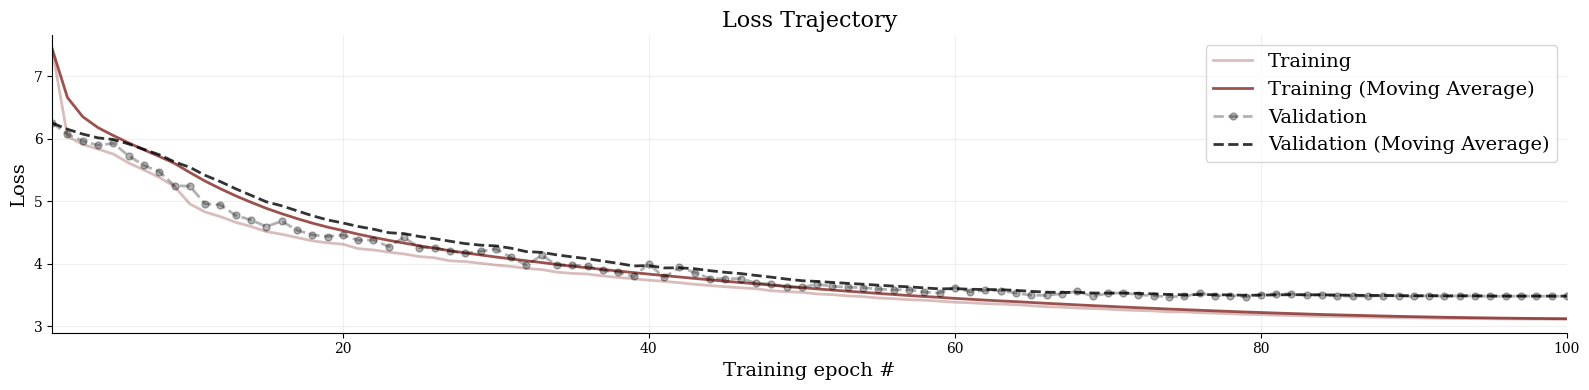

In [8]:
fig = workflow.plot_history(workflow.history)

## Verification

In [20]:
test_data = workflow.simulator.sample(
    batch_size=100,
    num_steps=NUM_STEPS,
    tile_to_steps=False
)

In [28]:
samples = workflow.sample(
    data={
        **{key: test_data[key] for key in workflow.simulator.data_keys},
        "missing_mask": test_data["missing_mask"],
    },
    num_samples=100,
    batch_size=8
)

Summarizing:   0%|          | 0/13 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/13 [00:00<?, ?batch/s]

### Time-varying Parameters

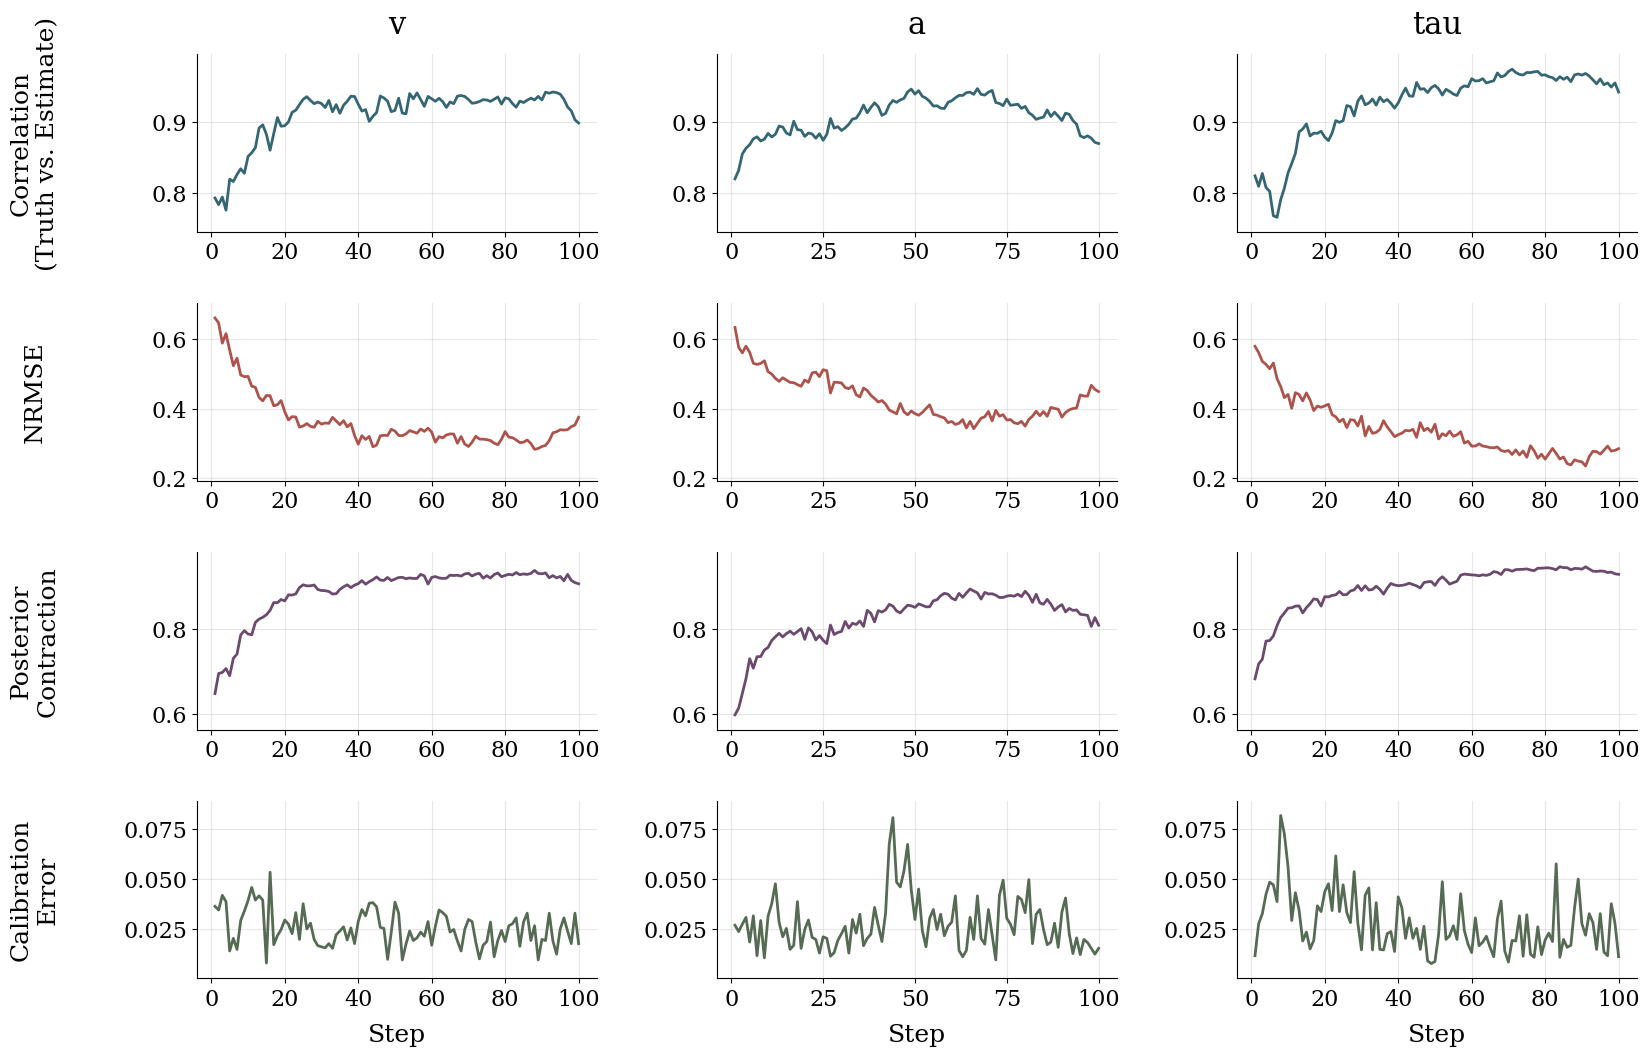

In [30]:
fig = workflow.verify_time_varying(test_data, samples)

In [33]:
time_step = 99
local_keys = workflow.simulator.local_keys
true = np.stack([test_data[k][:, time_step, 0] for k in local_keys], axis=-1)
estimates = np.stack([samples[k][:, :, time_step, 0] for k in local_keys], axis=-1)

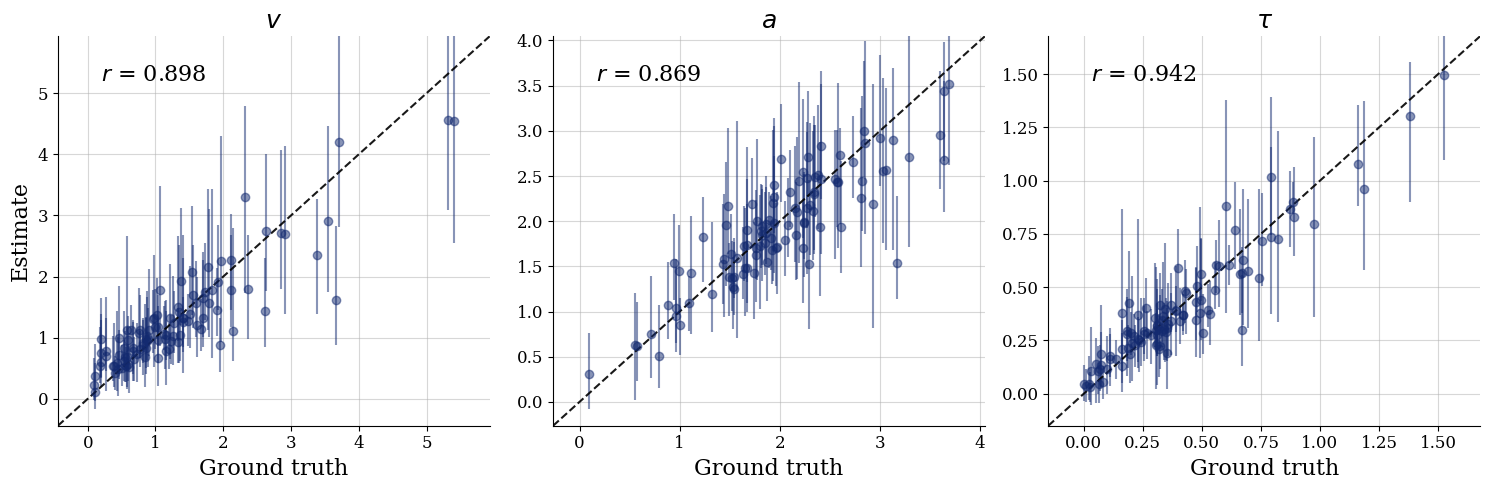

In [34]:
fig = bf.diagnostics.plots.recovery(
    estimates,
    true,
    variable_names = [r"$v$", r"$a$", r"$\tau$"],
)

### Time-invariant Parameters

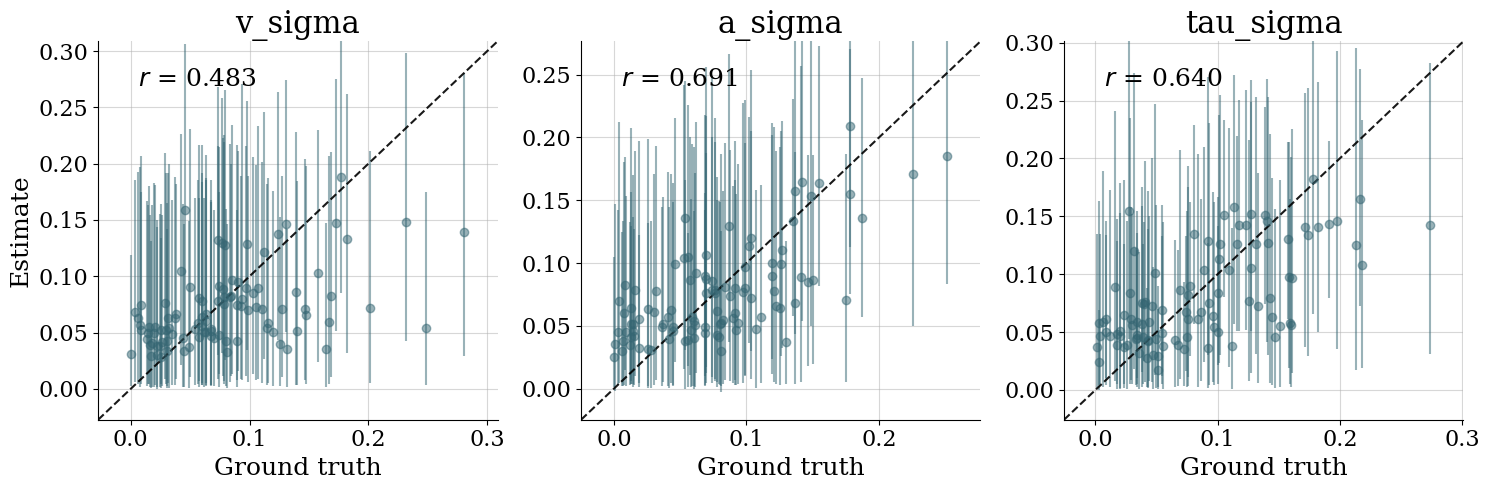

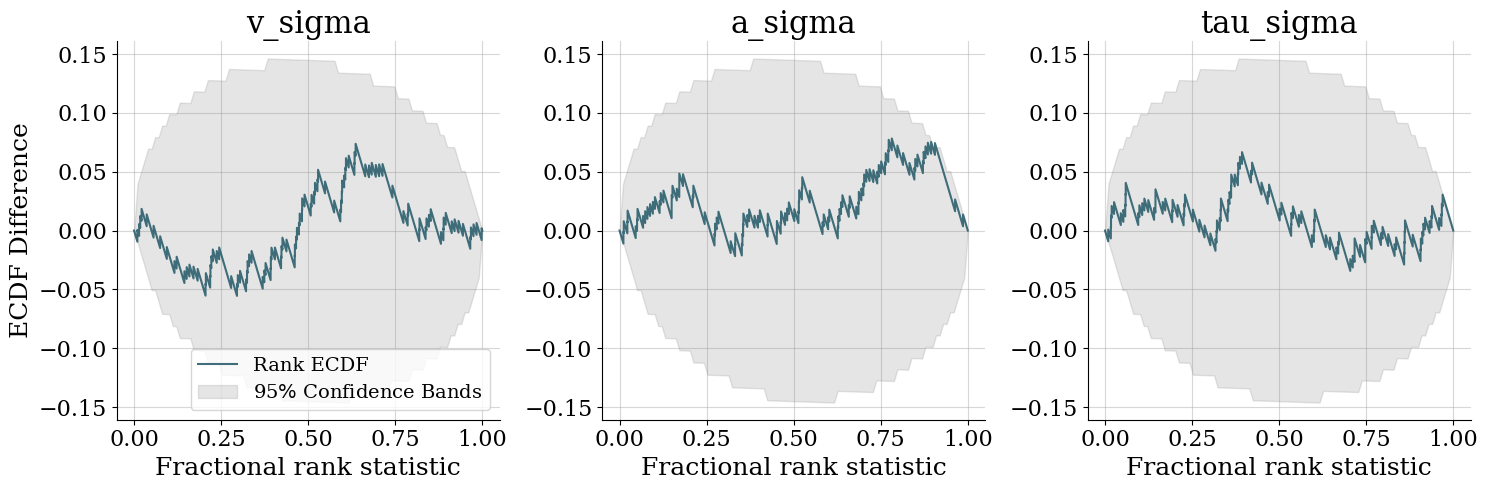

In [35]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    test_data,
    samples
)